| Company        | Ticker |
| -------------- | ------ |
| Microsoft      | MSFT   |
| Apple          | AAPL   |
| Amazon         | AMZN   |
| Tesla, Inc.    | TSLA   |
| NVIDIA         | NVDA   |

### India Stocks
| Company                   | Ticker      |
| ------------------------- | ----------- |
| Reliance Industries       | RELIANCE.NS |
| Tata Consultancy Services | TCS.NS      |
| Infosys                   | INFY.NS     |
| HDFC Bank                 | HDFCBANK.NS |
    
### Indices
| Index                        | Ticker |
| ---------------------------- | ------ |
| S&P 500                      | ^GSPC  |
| NIFTY 50                     | ^NSEI  |


In [49]:
import yfinance as yf

data = yf.download("MSFT", start="1986-01-01")

# print(data)

data.to_csv("msft.csv")

[*********************100%***********************]  1 of 1 completed


In [50]:
import pandas as pd

df = pd.read_csv('msft.csv')

df.head()
# df.tail()

,Price,Close,High,Low,Open,Volume
0,Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
1,Date,NaN,NaN,NaN,NaN,NaN
2,1986-03-13,0.05925340577960014,0.06189909260063727,0.053963249090163874,0.053963249090163874,1031788800
3,1986-03-14,0.06136946752667427,0.062428107324860184,0.059253404882922016,0.059253404882922016,308160000
4,1986-03-17,0.0624280609190464,0.06295707618674169,0.06136942190779835,0.06136942190779835,133171200


In [51]:
df = df.dropna()
df = df.drop_duplicates()

In [52]:
# reset index so Date becomes a column
df = df.drop(0)   # removes row with index 0,1
df = df.reset_index(drop=True)
df = df.rename(columns={"Price": "Date",})
# rename columns
df.head()

,Date,Close,High,Low,Open,Volume
0,1986-03-13,0.05925340577960014,0.06189909260063727,0.053963249090163874,0.053963249090163874,1031788800
1,1986-03-14,0.06136946752667427,0.062428107324860184,0.059253404882922016,0.059253404882922016,308160000
2,1986-03-17,0.0624280609190464,0.06295707618674169,0.06136942190779835,0.06136942190779835,133171200
3,1986-03-18,0.06084045022726059,0.0629571212903192,0.060311434580569284,0.0624281056436279,67766400
4,1986-03-19,0.059782423079013824,0.061369470129128884,0.059253407395642145,0.0608404544457572,47894400


In [53]:
df.dtypes

Date      str
Close     str
High      str
Low       str
Open      str
Volume    str
dtype: object

In [54]:
cols = df.columns.drop(["Date"])
df[cols] = df[cols].astype(float)

In [55]:
df.dtypes

Date          str
Close     float64
High      float64
Low       float64
Open      float64
Volume    float64
dtype: object

In [56]:
import datetime

def str_to_datetime(s):
  split = s.split('-')
  year, month, day = int(split[0]), int(split[1]), int(split[2])
  return datetime.datetime(year=year, month=month, day=day)

datetime_object = str_to_datetime('1986-03-19')
datetime_object

datetime.datetime(1986, 3, 19, 0, 0)

In [57]:
df['Date'] = df['Date'].apply(str_to_datetime)
df['Date']

0       1986-03-13
1       1986-03-14
2       1986-03-17
3       1986-03-18
4       1986-03-19
           ...    
10092   2026-04-06
10093   2026-04-07
10094   2026-04-08
10095   2026-04-09
10096   2026-04-10
Name: Date, Length: 10097, dtype: datetime64[us]

In [58]:
df["MA10"] = df["Close"].rolling(window=10).mean()
df["MA20"] = df["Close"].rolling(window=20).mean()

df["EMA10"] = df["Close"].ewm(span=10, adjust=False).mean()

In [59]:
def compute_rsi(series, period=14):
    delta = series.diff()

    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()

    rs = gain / (loss + 1e-9)
    rsi = 100 - (100 / (1 + rs))

    return rsi


df["RSI"] = compute_rsi(df["Close"], 14)

In [60]:
ema12 = df["Close"].ewm(span=12, adjust=False).mean()
ema26 = df["Close"].ewm(span=26, adjust=False).mean()

df["MACD"] = ema12 - ema26
df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()
df["MACD_Hist"] = df["MACD"] - df["MACD_Signal"]

In [61]:
df.index = df.pop('Date')
df

,Close,High,Low,Open,Volume,MA10,MA20,EMA10,RSI,MACD,MACD_Signal,MACD_Hist
Date,,,,,,,,,,,,
1986-03-13,0.059253,0.061899,0.053963,0.053963,1.031789e+09,NaN,NaN,0.059253,NaN,0.000000,0.000000,0.000000
1986-03-14,0.061369,0.062428,0.059253,0.059253,3.081600e+08,NaN,NaN,0.059638,NaN,0.000169,0.000034,0.000135
1986-03-17,0.062428,0.062957,0.061369,0.061369,1.331712e+08,NaN,NaN,0.060145,NaN,0.000384,0.000104,0.000280
1986-03-18,0.060840,0.062957,0.060311,0.062428,6.776640e+07,NaN,NaN,0.060272,NaN,0.000421,0.000167,0.000254
1986-03-19,0.059782,0.061369,0.059253,0.060840,4.789440e+07,NaN,NaN,0.060183,NaN,0.000361,0.000206,0.000155
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-06,372.880005,373.730011,369.500000,373.489990,1.614660e+07,369.435999,383.692999,372.870496,28.953520,-10.724691,-10.969346,0.244655
2026-04-07,372.290009,372.450012,366.559998,370.339996,2.144330e+07,368.364999,381.837000,372.764953,28.931032,-10.096103,-10.794697,0.698595
2026-04-08,374.329987,385.000000,371.410004,384.980011,3.306480e+07,368.523999,380.265498,373.049504,35.147998,-9.325830,-10.500924,1.175094


In [62]:
df= df.dropna()

In [63]:
cols = df.columns

In [64]:
from sklearn.preprocessing import MinMaxScaler

X_scaler = MinMaxScaler()
Y_scaler = MinMaxScaler()
temp = df[['Close']]

df[cols]= X_scaler.fit_transform(df[cols])

df[['Close']] = Y_scaler.fit_transform(temp)

In [65]:
import joblib

joblib.dump(X_scaler, "X_scaler.pkl")
joblib.dump(Y_scaler, "Y_scaler.pkl")

['Y_scaler.pkl']

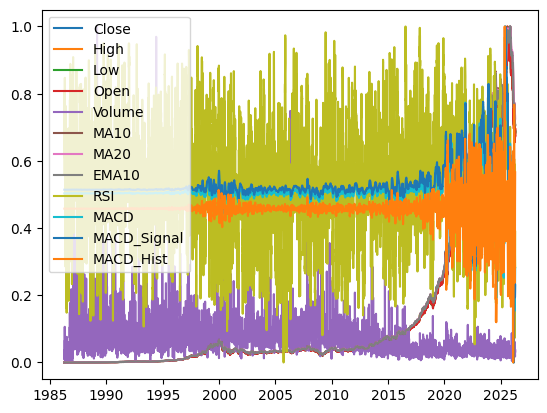

In [66]:
import matplotlib.pyplot as plt
for col in cols:
    plt.plot(df.index, df[col],label = col)

plt.legend()
plt.show()

##  Visual Example

### Dataset
```
Mar 22
Mar 23
Mar 24
Mar 25
Mar 26
Mar 29 ← next trading day
```

### For `n = 3`

Input: `[Mar22, Mar23, Mar24]`  
Target: `Mar25`

### Next iteration : find the next days in 7 days range in Mar 25 -> 25,26,29,.....

Input: `[Mar23, Mar24, Mar25]`  
Target: `Mar26`

### Next iteration : find the next days in 7 days range in Mar 26 -> 26,29,.....

Input: `[Mar24, Mar25, Mar26]`  
Target: `Mar29`


In [72]:
import numpy as np

def df_to_windowed_df(dataframe, first_date_str, last_date_str, n=3):
    first_date = str_to_datetime(first_date_str)
    last_date  = str_to_datetime(last_date_str)

    target_date = first_date

    dates = []
    X, Y = [], []

    last_time = False
    while True:
        df_subset = dataframe.loc[:target_date].tail(n+1)

        if len(df_subset) != n+1:
            print(f'Error: Window of size {n} is too large for date {target_date}')
            return

        values = df_subset[cols].to_numpy()
        x, y = values[:-1], values[-1][0]
        
        dates.append(target_date)
        X.append(x)
        Y.append(y)

        # stock markets are closed on sat,sun adn holidays so no data available for those days
        # so we seach for the days which  falls in the next 7 days of the target date to choose the next trading date
        next_week = dataframe.loc[target_date:target_date+datetime.timedelta(days=7)] 
        # chooses the next trading day top one is the previous trading day ,next one is the next trading day
        next_datetime_str = str(next_week.head(2).tail(1).index.values[0]) 
        next_date_str = next_datetime_str.split('T')[0]
        next_date = str_to_datetime(next_date_str)

        if last_time:
            break

        target_date = next_date

        if target_date == last_date:
            last_time = True

    return np.array(dates),np.array(X), np.array(Y)

# Start day second time around: '2021-03-25'
dates,X,y = df_to_windowed_df(df,
                                '1986-06-01',
                                '2026-04-01',
                                n=32)
print(X)
print(y)

[[[7.84064637e-06 5.74826659e-06 7.85942307e-06 ... 5.03379560e-01
   5.14237640e-01 4.57812186e-01]
  [1.17620876e-05 1.05395781e-05 1.08067151e-05 ... 5.03386915e-01
   5.14241708e-01 4.57822203e-01]
  [1.27421494e-05 1.05395608e-05 1.57199871e-05 ... 5.03393586e-01
   5.14246415e-01 4.57828706e-01]
  ...
  [1.96027064e-05 1.72458602e-05 1.96497159e-05 ... 5.03387338e-01
   5.14270631e-01 4.57749855e-01]
  [2.35230503e-05 2.10780564e-05 2.35794689e-05 ... 5.03392359e-01
   5.14269287e-01 4.57767171e-01]
  [2.64643400e-05 2.58692964e-05 2.65266908e-05 ... 5.03399396e-01
   5.14269743e-01 4.57785489e-01]]

 [[1.27421494e-05 1.05395608e-05 1.57199871e-05 ... 5.03393586e-01
   5.14246415e-01 4.57828706e-01]
  [8.82191598e-06 1.05396455e-05 1.17892133e-05 ... 5.03394013e-01
   5.14250274e-01 4.57820078e-01]
  [8.82191598e-06 7.66551586e-06 9.82434833e-06 ... 5.03394049e-01
   5.14253368e-01 4.57812312e-01]
  ...
  [2.64643400e-05 2.58692964e-05 2.65266908e-05 ... 5.03399396e-01
   5.14269

In [73]:
print(dates.shape)
print(X.shape)
print(y.shape)

(10036,)
(10036, 32, 12)
(10036,)


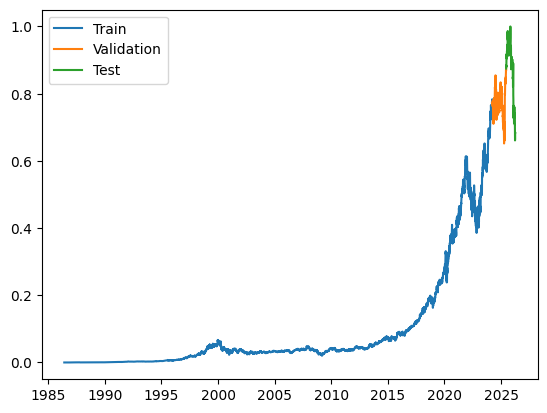

In [75]:
q_80 = int(len(dates) * .95)
q_90 = int(len(dates) * .98)
# 80% → Training
# 10% → Validation
# 10% → Testing

dates_train, X_train, y_train = dates[:q_80], X[:q_80,:,:], y[:q_80]

dates_val, X_val, y_val = dates[q_80:q_90], X[q_80:q_90], y[q_80:q_90]
dates_test, X_test, y_test = dates[q_90:], X[q_90:], y[q_90:]

plt.plot(dates_train, y_train)
plt.plot(dates_val, y_val)
plt.plot(dates_test, y_test)

plt.legend(['Train', 'Validation', 'Test'])

In [76]:
import tensorflow as tf
from tensorflow.keras import layers, models

timesteps = 32
features = 12   # change depending on your features

inputs = layers.Input(shape=(timesteps, features))

# CNN
x = layers.Conv1D(filters=64, kernel_size=3, activation="relu", padding="same")(inputs)
x = layers.MaxPooling1D(pool_size=2)(x)

# BiLSTM
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)

# Attention
attention = layers.Attention()([x, x])
x = layers.GlobalAveragePooling1D()(attention)

# Dense layers
x = layers.Dense(32, activation="relu")(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(1)(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                 ┃ Output Shape             ┃        Param # ┃ Connected to              ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)   │ (None, 32, 12)           │              0 │ -                         │
├──────────────────────────────┼──────────────────────────┼────────────────┼───────────────────────────┤
│ conv1d_1 (Conv1D)            │ (None, 32, 64)           │          2,368 │ input_layer_1[0][0]       │
├──────────────────────────────┼──────────────────────────┼────────────────┼───────────────────────────┤
│ max_pooling1d_1              │ (None, 16, 64)           │              0 │ conv1d_1[0][0]            │
│ (MaxPooling1D)               │                          │                │                           │
├──────────────────────────────┼──────────────────────────┼────────────────┼───────────────────────────┤
│ bidirectional_1              │ (None, 16, 128)          │         66,048 │ max_pooling1d_1[0][0]     │
│ (Bidirectional)              │                          │                │                           │
├──────────────────────────────┼──────────────────────────┼────────────────┼───────────────────────────┤
│ attention_1 (Attention)      │ (None, 16, 128)          │              0 │ bidirectional_1[0][0],    │
│                              │                          │                │ bidirectional_1[0][0]     │
├──────────────────────────────┼──────────────────────────┼────────────────┼───────────────────────────┤
│ global_average_pooling1d_1   │ (None, 128)              │              0 │ attention_1[0][0]         │
│ (GlobalAveragePooling1D)     │                          │                │                           │
├──────────────────────────────┼──────────────────────────┼────────────────┼───────────────────────────┤
│ dense_2 (Dense)              │ (None, 32)               │          4,128 │ global_average_pooling1d… │
├──────────────────────────────┼──────────────────────────┼────────────────┼───────────────────────────┤
│ dropout_1 (Dropout)          │ (None, 32)               │              0 │ dense_2[0][0]             │
├──────────────────────────────┼──────────────────────────┼────────────────┼───────────────────────────┤
│ dense_3 (Dense)              │ (None, 1)                │             33 │ dropout_1[0][0]           │
└──────────────────────────────┴──────────────────────────┴────────────────┴───────────────────────────┘

 Total params: 72,577 (283.50 KB)

 Trainable params: 72,577 (283.50 KB)

 Non-trainable params: 0 (0.00 B)

In [77]:
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100)

Epoch 1/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 0.0019 - mae: 0.0219 - val_loss: 0.0014 - val_mae: 0.0294
Epoch 2/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0011 - mae: 0.0162 - val_loss: 0.0026 - val_mae: 0.0398
Epoch 3/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0011 - mae: 0.0162 - val_loss: 0.0022 - val_mae: 0.0361
Epoch 4/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 9.3768e-04 - mae: 0.0151 - val_loss: 0.0032 - val_mae: 0.0475
Epoch 5/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 8.8697e-04 - mae: 0.0157 - val_loss: 0.0026 - val_mae: 0.0413
Epoch 6/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 8.7262e-04 - mae: 0.0157 - val_loss: 0.0039 - val_mae: 0.0556
Epoch 7/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 8.7734e-04 - mae: 0.0158 - val_loss: 0.0013 - val_mae: 0.0308
Epoch 8/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 8.5629e-04 - mae: 0.0159 - val_loss: 0.0015 - val_mae: 0.0339
Epoch 9/100
298/298 

298/298 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


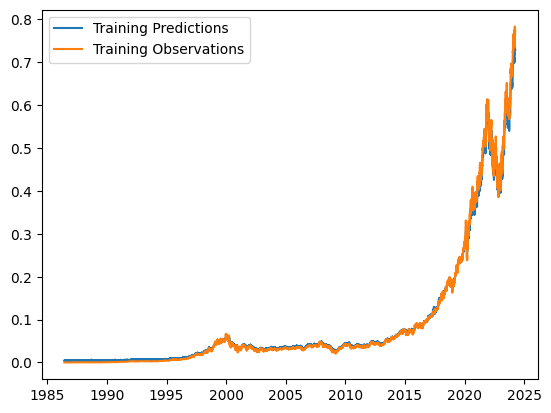

In [78]:
train_predictions = model.predict(X_train).flatten()

plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.legend(['Training Predictions', 'Training Observations'])

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


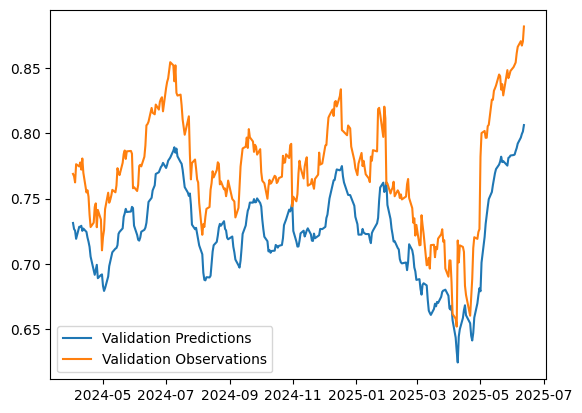

In [79]:
val_predictions = model.predict(X_val).flatten()

plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.legend(['Validation Predictions', 'Validation Observations'])

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


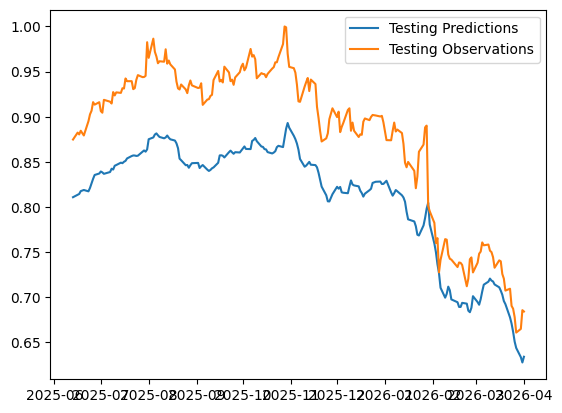

In [80]:
test_predictions = model.predict(X_test).flatten()

plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(['Testing Predictions', 'Testing Observations'])

In [31]:
model.save("microsoft_004_stock_model.keras")

In [32]:
print("X scaler min:", X_scaler.data_min_)
print("X scaler max:", X_scaler.data_max_)
print("X scaler range:", X_scaler.data_range_)
print("X scaler scale:", X_scaler.scale_)
print("X scaler min offset:", X_scaler.min_)

X scaler min: [ 3.43587494e+01  3.48944661e+01  3.42141534e+01  3.45203208e+01
  5.85590000e+06  3.51831161e+01  3.56028109e+01  3.52770066e+01
  6.80609693e+00 -1.88481670e+01 -1.76814259e+01 -6.19242109e+00]
X scaler max: [5.39825256e+02 5.52242002e+02 5.38530652e+02 5.52023241e+02
 1.35227100e+08 5.23633557e+02 5.19582895e+02 5.25596853e+02
 9.91121658e+01 1.85959513e+01 1.67023630e+01 7.33462103e+00]
X scaler range: [5.05466507e+02 5.17347536e+02 5.04316499e+02 5.17502920e+02
 1.29371200e+08 4.88450441e+02 4.83980084e+02 4.90319847e+02
 9.23060689e+01 3.74441183e+01 3.43837889e+01 1.35270421e+01]
X scaler scale: [1.97837045e-03 1.93293663e-03 1.98288179e-03 1.93235625e-03
 7.72969564e-09 2.04729061e-03 2.06620072e-03 2.03948506e-03
 1.08335239e-02 2.67064641e-02 2.90834731e-02 7.39259914e-02]
X scaler min offset: [-0.06797433 -0.06744879 -0.06784262 -0.06670556 -0.04526432 -0.07203006
 -0.07356255 -0.07194693 -0.07373401  0.5033679   0.51423727  0.45778087]


In [33]:
print("Y scaler min:", Y_scaler.data_min_)
print("Y scaler max:", Y_scaler.data_max_)
print("Y scaler range:", Y_scaler.data_range_)
print("Y scaler scale:", Y_scaler.scale_)
print("Y scaler min offset:", Y_scaler.min_)

Y scaler min: [34.35874939]
Y scaler max: [539.82525635]
Y scaler range: [505.46650696]
Y scaler scale: [0.00197837]
Y scaler min offset: [-0.06797433]


In [82]:
import yfinance as yf
import numpy as np
import pandas as pd
import joblib
from tensorflow import keras

# -------------------------------
# Load model and scalers
# -------------------------------

model = keras.models.load_model("E:/3rd_sem_project/stock_price_predictor_models/v1/microsoft_004_stock_model.keras")

# X_scaler = joblib.load("E:/3rd_sem_project/stock_price_predictor_models/v1/X_scaler.pkl")
# Y_scaler = joblib.load("E:/3rd_sem_project/stock_price_predictor_models/v1/Y_scaler.pkl")

# -------------------------------
# Download stock data
# -------------------------------

ticker = "MSFT"

# need extra data because indicators need history
data = yf.download(ticker, period="120d")

# -------------------------------
# Feature Engineering
# -------------------------------

data["MA10"] = data["Close"].rolling(window=10).mean()
data["MA20"] = data["Close"].rolling(window=20).mean()

data["EMA10"] = data["Close"].ewm(span=10, adjust=False).mean()

data["RSI"] = compute_rsi(data["Close"], 14)

ema12 = data["Close"].ewm(span=12, adjust=False).mean()
ema26 = data["Close"].ewm(span=26, adjust=False).mean()

data["MACD"] = ema12 - ema26
data["MACD_Signal"] = data["MACD"].ewm(span=9, adjust=False).mean()
data["MACD_Hist"] = data["MACD"] - data["MACD_Signal"]

# drop NaN rows from indicators
data = data.dropna()

# -------------------------------
# Feature columns (must match training order)
# -------------------------------

cols = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "MA10",
    "MA20",
    "EMA10",
    "RSI",
    "MACD",
    "MACD_Signal",
    "MACD_Hist"
]

# -------------------------------
# Prepare last 32 timesteps
# -------------------------------

window_size = 32

prices = data[cols].tail(window_size).values

# scale features
scaled = X_scaler.transform(prices)

# reshape for model
X_input = scaled.reshape(1, window_size, len(cols))

# -------------------------------
# Prediction
# -------------------------------

pred_scaled = model.predict(X_input)

pred_price = Y_scaler.inverse_transform(pred_scaled)

print("Predicted next close price:", pred_price[0][0])

[*********************100%***********************]  1 of 1 completed
E:\3rd_sem_project\stock_price_predictor_models\v1\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step
Predicted next close price: 370.2817
